In [1]:
import pandas as pd
import requests
import io
import json
import numpy as np
from fpdf import FPDF
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.dates as md
from fpdf import FPDF
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as ticker
import plotly.graph_objects as go
import plotly.express as px
import plotly.offline as pyo




In [2]:
report_type= 'fleet'
first_Period= '2023'
second_Period= '2024'
first_period_min= '2023-01-01'
first_period_max= '2023-12-31'
second_period_min= '2024-01-01'
second_period_max= '2024-12-31'
#vessel_name= 'HOSHI - 9453298'
fleet= 'Fleet 1'
#class_name: null
moving_average= '1'
moving_average: 1

In [3]:
import json 

text_file_path = 'eeoi.txt'

# Read the content of the text file and load it into a JSON object
with open(text_file_path, 'r') as file:
    s = json.load(file)  
# Now, you can use the 's' variable to work with your JSON data
print(s)

{'data': {'year1': {'finaldata': [{'imo': '9138783', 'vessel_name': 'MSC BRIDGE', 'fleet': '1', 'class': 'BRIDGE', 'distance_covered': 28368.7, 'fuel_boiler_dstlt_uls': 0, 'fuel_aux_dstlt_uls': 0, 'teu_transport_work': 26015357.6, 'cargo_transport_work': 267562495.9, 'fuel_boiler_tnktnr_dstlt_vls': 431.83, 'fuel_aux_tnktnr_dstlt_vls': 400.08, 'fuel_me_tnktnr_dstlt_vls': 4.55, 'fuel_me_dstlt_uls': 0, 'fuel_boiler_dstlt_vls': 0, 'fuel_aux_dstlt_vls': 0, 'fuel_me_dstlt_vls': 0, 'fuel_boiler_rsdl_uls': 0, 'fuel_aux_rsdl_uls': 0, 'fuel_me_rsdl_uls': 0, 'fuel_boiler_rsdl_vls': 3.08, 'fuel_aux_rsdl_vls': 451.67, 'fuel_me_rsdl_vls': 2299.95, 'fuel_boiler_rsdl_hs': 0, 'fuel_aux_rsdl_hs': 0, 'fuel_me_rsdl_hs': 0, 'miles_by_gps': 25765, 'manvrng_miles_by_gps': 2603.7, 'fuel_hs': 0, 'fuel_ls': 2754.7, 'fuel_mdo': 0, 'fuel_mgo': 836.46, 'fuel_mgo_ls': 0, 'me_fuel_only_steaming_time': 241.7, 'fuel_me_hs': 0, 'fuel_aux_hs': 0, 'fuel_boiler_hs': 0, 'fuel_me_ls': 117.2, 'fuel_aux_ls': 28.85, 'fuel_boil

In [4]:
import pandas as pd
from datetime import datetime



vsl_name = pd.DataFrame.from_dict(s['vessel_data'])  
col_vsl = dict(zip(vsl_name['imo'], vsl_name['name']))  
if first_Period is None and second_Period is None:  
    date_object_first_Period = datetime.strptime(first_period_max, '%Y-%m-%d')
    first_Period_year = date_object_first_Period.year
    date_object_second_Period = datetime.strptime(second_period_max, '%Y-%m-%d')
    second_Period_year = date_object_second_Period.year
    Heading = "YEAR" + "  " + str(first_Period_year) + " - " + str(second_Period_year) + "  " + "EEOI ANALYSIS"
else:
    Heading = "YEAR" + "  " + first_Period + " - " + second_Period + "  " + "EEOI ANALYSIS"
    first_Period_year, second_Period_year = first_Period, second_Period


# if report_type == 'vessel':
#     # vsl_name = pd.DataFrame.from_dict(s['vessel_data'])
#     # col_vsl = dict(zip(vsl_name['imo'], vsl_name['name']))
#     s = s['data'] 



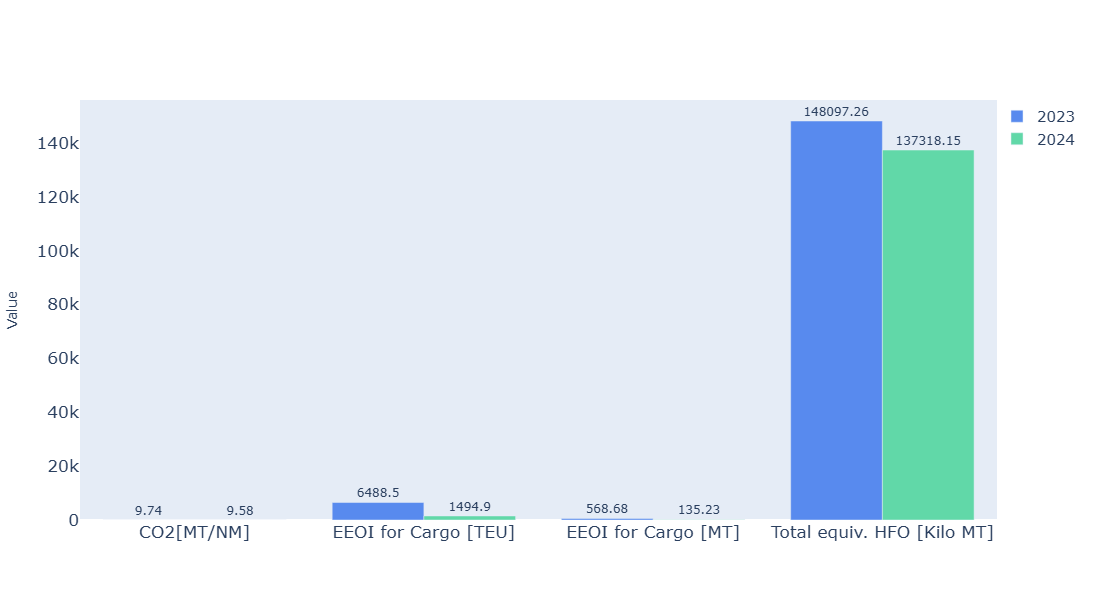

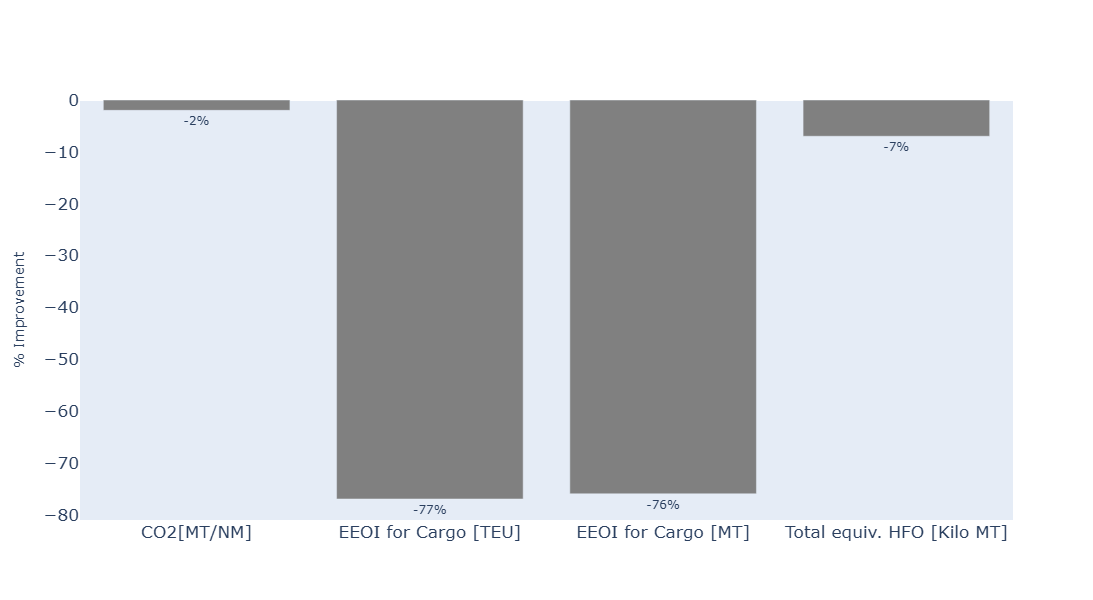

C:\Users\akshaya\AppData\Local\Temp\ipykernel_160272\1524889368.py:142: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [99]:
if report_type == "fleet":
    Table1 = pd.DataFrame.from_dict(s['data']['table1']['table1']).fillna(0)
    Table1['improvement'] = Table1['improvement'].astype(float).astype(int)
    Table1_str = Table1[['index', 'year1', 'year2', 'improvement']].astype(str)
    Table1_str['improvement'] = Table1_str['improvement'] + ' %'

    Table_1_head_Year = [['Year', first_Period, second_Period, '% Improvement']] if all((first_Period, second_Period)) else [['Year', str(first_Period_year), str(second_Period_year), '% Improvement']]
    Table_1_Year = Table_1_head_Year + Table1_str.values.tolist()

    # 2nd Table
    Table_2 = Table1.set_index(['index'])
    Table_2 = Table_2.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]].reset_index()

    Table_2 = Table_2.rename({'improvement': 'Improvement (%)', 'year1': first_Period, 'year2': second_Period, 'index': 'Year'}, axis=1) if all((first_Period, second_Period)) else Table_2.rename({'improvement': 'Improvement (%)', 'year1': str(first_Period_year), 'year2': str(second_Period_year), 'index': 'Year'}, axis=1)

    Table_2_new = Table_2.T.reset_index().T.set_index(0).T
    Table_2_str = Table_2_new.astype(str)


    FirstPeriodData = pd.DataFrame.from_dict(s['data']['FirstPeriodData'])
    FirstPeriodData_1 = FirstPeriodData[['Vessel Name', 'Cargo Total (MT)', 'Cargo Total (TEU)', 'Distance (NM)','Number of Voyages','Total CO2 (MT)',
                                    'Equivalent HFO (MT)','EEOI (gm/MT-NM)', 'EEOI (gm/TEU-NM)','Fuel per Miles(Kg/NM)','Distance per Voyage (NM)',
                                    'Fuel Consumption per Voyage (MT)']].round(2)
    # FirstPeriodData_1['eeoi_mt'] = FirstPeriodData_1['eeoi_mt'].astype('float32')
    # FirstPeriodData_1['eeoi_teu'] = FirstPeriodData_1['eeoi_teu'].astype('float32')
    FirstPeriodData_str = FirstPeriodData_1.astype(str)
    SecondPeriodData = pd.DataFrame.from_dict(s['data']['SecondPeriodData'])
    SecondPeriodData['Vessel Name'].nunique()
    SecondPeriodData_1 = SecondPeriodData[['Vessel Name', 'Cargo Total (MT)', 'Cargo Total (TEU)', 'Distance (NM)','Number of Voyages','Total CO2 (MT)',
                                    'Equivalent HFO (MT)','EEOI (gm/MT-NM)', 'EEOI (gm/TEU-NM)','Fuel per Miles(Kg/NM)','Distance per Voyage (NM)',
                                    'Fuel Consumption per Voyage (MT)']].round(2)
    SecondPeriodData_str = SecondPeriodData_1.astype(str)


    vsl_name = pd.DataFrame.from_dict(s['vessel_data'])
    col_vsl = dict(zip(vsl_name['imo'], vsl_name['name']))
    #s = s['data']

    Year1_Graph = pd.DataFrame.from_dict(s['data']['year1']['finaldata']).round(2)
    Year2_Graph = pd.DataFrame.from_dict(s['data']['year2']['finaldata']).round(2)
    EEOI_Analysis = Table1.set_index(['index'])
    EEOI_Analysis = EEOI_Analysis.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]]
    EEOI_Analysis = EEOI_Analysis[['year1', 'year2']]

    EEOI_Analysis_new = EEOI_Analysis.rename({"year1": first_Period, 'year2': second_Period}, axis=1) if all((first_Period, second_Period)) else EEOI_Analysis.rename({"year1": str(first_Period_year), 'year2': str(second_Period_year)}, axis=1)

    # EEOI_Analysis_Graph = EEOI_Analysis_new.plot.bar(rot=0, color={first_Period: "#588aee", second_Period: "#61d8a8"}, width=0.8, figsize=(10, 6))

    EEOI_Analysis = Table1.set_index(['index'])
    EEOI_Analysis = EEOI_Analysis.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]]
    EEOI_Analysis = EEOI_Analysis[['year1', 'year2']]

    EEOI_Analysis_1 = EEOI_Analysis_new.columns[0]
    EEOI_Analysis_2 = EEOI_Analysis_new.columns[1]

    # Create a bar chart for each trace with values above the bars
    trace1 = go.Bar(
        x=EEOI_Analysis.index,
        y=EEOI_Analysis['year1'],
        text=EEOI_Analysis['year1'].round(2),  # Adjust rounding as needed
        textposition='outside',  # Display text labels outside the bars
        name=EEOI_Analysis_1,
        marker=dict(color="#588aee")
    )

    trace2 = go.Bar(
        x=EEOI_Analysis.index,
        y=EEOI_Analysis['year2'],
        text=EEOI_Analysis['year2'].round(2),
        textposition='outside',
        name=EEOI_Analysis_2,  # Use the dynamically generated legend label
        marker=dict(color="#61d8a8")
    )

    layout = go.Layout(
        xaxis=dict(
            title=' ',
            tickfont=dict(size=17),
            showgrid=False  # Correct syntax for showgrid
        ),
        yaxis=dict(
            title='Value',
            tickfont=dict(size=17),
            showgrid=False  # Correct syntax for showgrid
        ),
        showlegend=True,
        legend=dict(
            x=1,  # Adjust the x position of the legend
            y=1,  # Adjust the y position of the legend
            font=dict(size=15),  # Adjust the font size of the legend
            bgcolor='rgba(0, 0, 0, 0)'  # Make the legend background transparent
        ),
        width=1050,
        height=600
    )

    fig = go.Figure(data=[trace1, trace2], layout=layout)
    fig.show()
    plot_div = pyo.plot(fig, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})

    Improvement_Percent = Table1.set_index(['index'])
    Improvement_Percent = Improvement_Percent.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]]
    Improvement_Percent = Improvement_Percent[['improvement']].reset_index()
    Improvement_Percent = Improvement_Percent.set_index(['index'])

    fig1 = go.Figure()

    fig1.add_trace(go.Bar(
        x=Improvement_Percent.index,
        y=Improvement_Percent['improvement'],
        text=Improvement_Percent['improvement'].astype('str') + '%',
        textposition='outside',  # Display text outside the bar
        marker=dict(color='#808080')  
    ))

    layout = go.Layout(
        xaxis=dict(
            title='',
            tickfont=dict(size=17),
            showgrid=False  # Correct syntax for showgrid
        ),
        yaxis=dict(
            title='% Improvement',
            tickfont=dict(size=17),
            showgrid=False  # Correct syntax for showgrid
        ),
        showlegend=False,
        width=1000,
        height=600
    )
    # Format y-axis tick labels as percentages
    layout['yaxis']['tickformat'] = '.3f%'

    fig1.update_layout(layout)

    fig1.show()

    plot_div2 = pyo.plot(fig1, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})
    
    Energy_Efficiency = Year1_Graph[['imo', 'eeoi_mt']].copy()  
    
    # Check if 'second_Period' is not None and perform mapping for that period
    if second_Period is not None:
        # Use .loc[] to safely assign values to a column
        Energy_Efficiency.loc[:, second_Period] = Energy_Efficiency['imo'].map(Year2_Graph.set_index('imo')['eeoi_mt'])
        Energy_Efficiency = Energy_Efficiency.sort_values(by=second_Period)
    else:
        Energy_Efficiency.loc[:, str(second_Period_year)] = Energy_Efficiency['imo'].map(Year2_Graph.set_index('imo')['eeoi_mt'])
        Energy_Efficiency = Energy_Efficiency.sort_values(by=str(second_Period_year))
    
    # Add the vessel names
    Energy_Efficiency['Vessel Name'] = Energy_Efficiency['imo'].map(col_vsl)
    Energy_Efficiency['Vessel - IMO'] = Energy_Efficiency['Vessel Name']
    
    # Rename the 'eeoi_mt' column
    Energy_Efficiency = Energy_Efficiency.rename({'eeoi_mt': str(first_Period_year)}, axis=1)
    
    # Check if both 'first_Period' and 'second_Period' are provided
    if first_Period is not None and second_Period is not None:
        # Melt data if both periods are provided
        melted_data = pd.melt(Energy_Efficiency, id_vars=['Vessel - IMO'], value_vars=[first_Period, second_Period], var_name='Period', value_name='Energy_Efficiency')
        
        # Plot the bar chart using Plotly
        Energy_Efficiency_graph = px.bar(
            melted_data,
            x='Vessel - IMO',
            y='Energy_Efficiency',
            color='Period',
            color_discrete_sequence=['#c44332', '#1a75c1'],  # Medium red and blue
            labels={'value': 'Energy Efficiency (g/Ton-Nm)'},
            title='Energy Efficiency',
        )
    else:
        # Plot the bar chart using Plotly without melting
        Energy_Efficiency_graph = px.bar(
            Energy_Efficiency,
            x='Vessel - IMO',
            y=[str(first_Period_year), str(second_Period_year)],
            color_discrete_sequence=['#c44332', '#1a75c1'],  # Medium red and blue
            labels={'value': 'Energy Efficiency (g/Ton-Nm)'},
            title='Energy Efficiency',
        )
    
    # Update the layout for the plot
    layout = go.Layout(
        title=dict(
            text='Energy Efficiency',
            font=dict(size=20, family='Roboto, sans-serif', color='black'),
            x=0.5  # Center the title horizontally
        ),
        xaxis=dict(
            title='Vessel Name',
            tickfont=dict(size=18, family='Roboto, sans-serif'),
            showgrid=False
        ),
        yaxis=dict(
            title='Energy Efficiency (g/Ton-Nm)',
            tickfont=dict(size=18, family='Roboto, sans-serif'),
            showgrid=False
        ),
        legend=dict(
            title='',
            font=dict(size=15),
            bgcolor='rgba(0, 0, 0, 0)'  # Transparent background for the legend
        ),
        barmode='group',  # Group bars
        width=1050,
        height=750
    )
    
    Energy_Efficiency_graph.update_layout(layout)
    
    # Generate the plot
    plot_div5 = pyo.plot(Energy_Efficiency_graph, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})
    fig.show()
    

else:
    pass

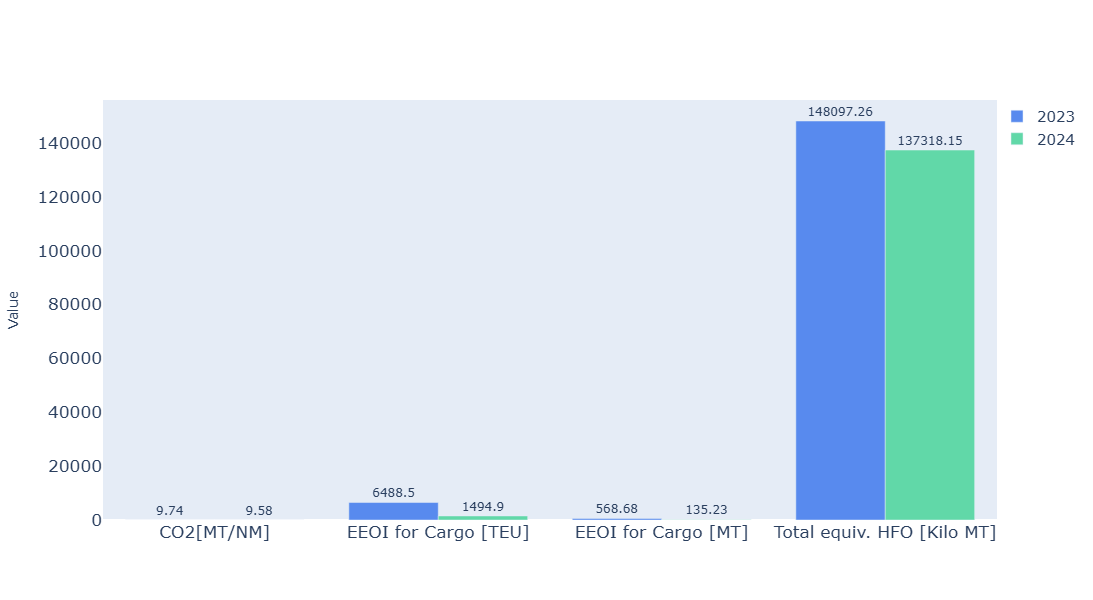

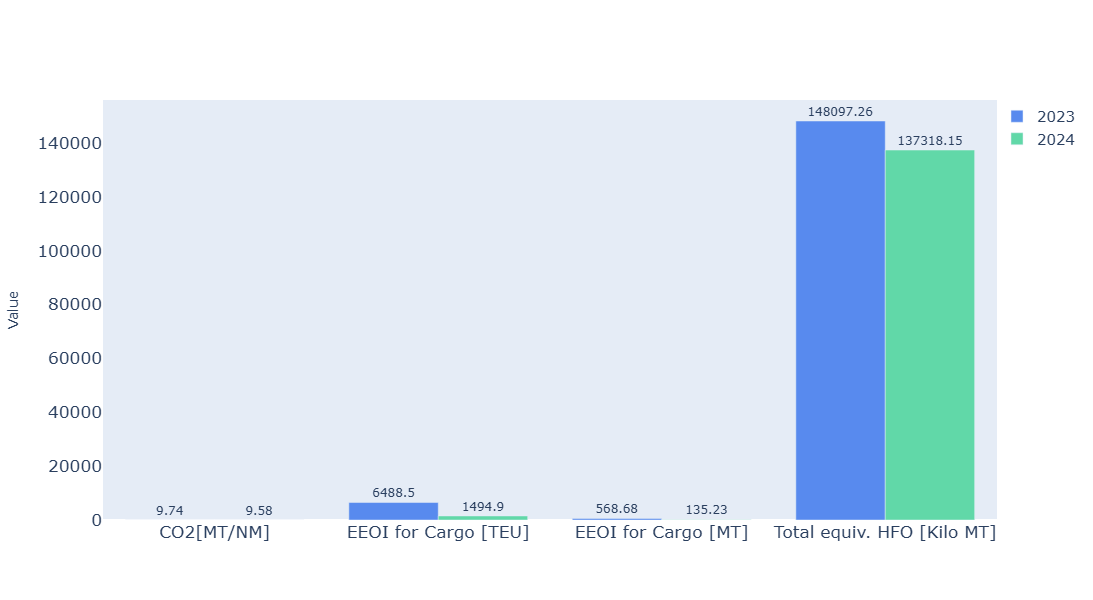

In [91]:
if report_type == "fleet":
    Table1 = pd.DataFrame.from_dict(s['data']['table1']['table1']).fillna(0)
    Table1['improvement'] = Table1['improvement'].astype(float).astype(int)
    Table1_str = Table1[['index', 'year1', 'year2', 'improvement']].astype(str)
    Table1_str['improvement'] = Table1_str['improvement'] + ' %'

    Table_1_head_Year = [['Year', first_Period, second_Period, '% Improvement']] if all((first_Period, second_Period)) else [['Year', str(first_Period_year), str(second_Period_year), '% Improvement']]
    Table_1_Year = Table_1_head_Year + Table1_str.values.tolist()

    # 2nd Table
    Table_2 = Table1.set_index(['index'])
    Table_2 = Table_2.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]].reset_index()

    Table_2 = Table_2.rename({'improvement': 'Improvement (%)', 'year1': first_Period, 'year2': second_Period, 'index': 'Year'}, axis=1) if all((first_Period, second_Period)) else Table_2.rename({'improvement': 'Improvement (%)', 'year1': str(first_Period_year), 'year2': str(second_Period_year), 'index': 'Year'}, axis=1)

    Table_2_new = Table_2.T.reset_index().T.set_index(0).T
    Table_2_str = Table_2_new.astype(str)


    FirstPeriodData = pd.DataFrame.from_dict(s['data']['FirstPeriodData'])
    FirstPeriodData_1 = FirstPeriodData[['Vessel Name', 'Cargo Total (MT)', 'Cargo Total (TEU)', 'Distance (NM)','Number of Voyages','Total CO2 (MT)',
                                    'Equivalent HFO (MT)','EEOI (gm/MT-NM)', 'EEOI (gm/TEU-NM)','Fuel per Miles(Kg/NM)','Distance per Voyage (NM)',
                                    'Fuel Consumption per Voyage (MT)']].round(2)
    # FirstPeriodData_1['eeoi_mt'] = FirstPeriodData_1['eeoi_mt'].astype('float32')
    # FirstPeriodData_1['eeoi_teu'] = FirstPeriodData_1['eeoi_teu'].astype('float32')
    FirstPeriodData_str = FirstPeriodData_1.astype(str)
    SecondPeriodData = pd.DataFrame.from_dict(s['data']['SecondPeriodData'])
    SecondPeriodData['Vessel Name'].nunique()
    SecondPeriodData_1 = SecondPeriodData[['Vessel Name', 'Cargo Total (MT)', 'Cargo Total (TEU)', 'Distance (NM)','Number of Voyages','Total CO2 (MT)',
                                    'Equivalent HFO (MT)','EEOI (gm/MT-NM)', 'EEOI (gm/TEU-NM)','Fuel per Miles(Kg/NM)','Distance per Voyage (NM)',
                                    'Fuel Consumption per Voyage (MT)']].round(2)
    SecondPeriodData_str = SecondPeriodData_1.astype(str)


    vsl_name = pd.DataFrame.from_dict(s['vessel_data'])
    col_vsl = dict(zip(vsl_name['imo'], vsl_name['name']))
    #s = s['data']

    Year1_Graph = pd.DataFrame.from_dict(s['data']['year1']['finaldata']).round(2)
    Year2_Graph = pd.DataFrame.from_dict(s['data']['year2']['finaldata']).round(2)
    EEOI_Analysis = Table1.set_index(['index'])
    EEOI_Analysis = EEOI_Analysis.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]]
    EEOI_Analysis = EEOI_Analysis[['year1', 'year2']]

    EEOI_Analysis_new = EEOI_Analysis.rename({"year1": first_Period, 'year2': second_Period}, axis=1) if all((first_Period, second_Period)) else EEOI_Analysis.rename({"year1": str(first_Period_year), 'year2': str(second_Period_year)}, axis=1)

    # EEOI_Analysis_Graph = EEOI_Analysis_new.plot.bar(rot=0, color={first_Period: "#588aee", second_Period: "#61d8a8"}, width=0.8, figsize=(10, 6))

    EEOI_Analysis = Table1.set_index(['index'])
    EEOI_Analysis = EEOI_Analysis.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]]
    EEOI_Analysis = EEOI_Analysis[['year1', 'year2']]

    EEOI_Analysis_1 = EEOI_Analysis_new.columns[0]
    EEOI_Analysis_2 = EEOI_Analysis_new.columns[1]

    # Create a bar chart for each trace with values above the bars
    trace1 = go.Bar(
        x=EEOI_Analysis.index,
        y=EEOI_Analysis['year1'],
        text=EEOI_Analysis['year1'].round(2),  # Adjust rounding as needed
        textposition='outside',  # Display text labels outside the bars
        name=EEOI_Analysis_1,
        marker=dict(color="#588aee")
    )

    trace2 = go.Bar(
        x=EEOI_Analysis.index,
        y=EEOI_Analysis['year2'],
        text=EEOI_Analysis['year2'].round(2),
        textposition='outside',
        name=EEOI_Analysis_2,  # Use the dynamically generated legend label
        marker=dict(color="#61d8a8")
    )

    layout = go.Layout(
        xaxis=dict(
            title=' ',
            tickfont=dict(size=17),
            showgrid=False  # Correct syntax for showgrid
        ),
        yaxis=dict(
            title='Value',
            tickfont=dict(size=17),
            showgrid=False  # Correct syntax for showgrid
        ),
        showlegend=True,
        legend=dict(
            x=1,  # Adjust the x position of the legend
            y=1,  # Adjust the y position of the legend
            font=dict(size=15),  # Adjust the font size of the legend
            bgcolor='rgba(0, 0, 0, 0)'  # Make the legend background transparent
        ),
        width=1050,
        height=600
    )

    fig = go.Figure(data=[trace1, trace2], layout=layout)
    #fig.show()
    plot_div = pyo.plot(fig, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})


    # Format y-axis tick labels as percentages
    layout['yaxis']['tickformat'] = '.3f%'

    fig.update_layout(layout)

    fig.show()

    plot_div2 = pyo.plot(fig, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})
    
    '**********************************************************************************************************************************************'
    # Ensure that you're working with a fresh copy of the DataFrame to avoid 'SettingWithCopyWarning'
    Energy_Efficiency = Year1_Graph[['imo', 'eeoi_mt']].copy()  # Create a fresh copy
    
    # Check if 'second_Period' is not None and perform mapping for that period
    if second_Period is not None:
        # Use .loc[] to safely assign values to a column
        Energy_Efficiency.loc[:, second_Period] = Energy_Efficiency['imo'].map(Year2_Graph.set_index('imo')['eeoi_mt'])
        Energy_Efficiency = Energy_Efficiency.sort_values(by=second_Period)
    else:
        Energy_Efficiency.loc[:, str(second_Period_year)] = Energy_Efficiency['imo'].map(Year2_Graph.set_index('imo')['eeoi_mt'])
        Energy_Efficiency = Energy_Efficiency.sort_values(by=str(second_Period_year))
    
    # Add the vessel names
    Energy_Efficiency['Vessel Name'] = Energy_Efficiency['imo'].map(col_vsl)
    Energy_Efficiency['Vessel - IMO'] = Energy_Efficiency['Vessel Name']
    
    # Rename the 'eeoi_mt' column
    Energy_Efficiency = Energy_Efficiency.rename({'eeoi_mt': str(first_Period_year)}, axis=1)
    
    # Check if both 'first_Period' and 'second_Period' are provided
    if first_Period is not None and second_Period is not None:
        # Melt data if both periods are provided
        melted_data = pd.melt(Energy_Efficiency, id_vars=['Vessel - IMO'], value_vars=[first_Period, second_Period], var_name='Period', value_name='Energy_Efficiency')
        
        # Plot the bar chart using Plotly
        Energy_Efficiency_graph = px.bar(
            melted_data,
            x='Vessel - IMO',
            y='Energy_Efficiency',
            color='Period',
            color_discrete_sequence=['#c44332', '#1a75c1'],  # Medium red and blue
            labels={'value': 'Energy Efficiency (g/Ton-Nm)'},
            title='Energy Efficiency',
        )
    else:
        # Plot the bar chart using Plotly without melting
        Energy_Efficiency_graph = px.bar(
            Energy_Efficiency,
            x='Vessel - IMO',
            y=[str(first_Period_year), str(second_Period_year)],
            color_discrete_sequence=['#c44332', '#1a75c1'],  # Medium red and blue
            labels={'value': 'Energy Efficiency (g/Ton-Nm)'},
            title='Energy Efficiency',
        )
    
    # Update the layout for the plot
    layout = go.Layout(
        title=dict(
            text='Energy Efficiency',
            font=dict(size=20, family='Roboto, sans-serif', color='black'),
            x=0.5  # Center the title horizontally
        ),
        xaxis=dict(
            title='Vessel Name',
            tickfont=dict(size=18, family='Roboto, sans-serif'),
            showgrid=False
        ),
        yaxis=dict(
            title='Energy Efficiency (g/Ton-Nm)',
            tickfont=dict(size=18, family='Roboto, sans-serif'),
            showgrid=False
        ),
        legend=dict(
            title='',
            font=dict(size=15),
            bgcolor='rgba(0, 0, 0, 0)'  # Transparent background for the legend
        ),
        barmode='group',  # Group bars
        width=1050,
        height=750
    )
    
    Energy_Efficiency_graph.update_layout(layout)
    
    # Generate the plot
    plot_div5 = pyo.plot(Energy_Efficiency_graph, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})
    fig.show()





    Table_3_head_Year=[['Vessel Name','Cargomt','Cargoteu','Distance','EEOI_Voy_no','Totalco2_mt','Totalco2_kgnm',
                                                    'EEOI_mt', 'EEOI_teu','Fuelkg_nm','Average Distance','Average Fuelcons']]

    Table_3_Year1 =Table_3_head_Year+ FirstPeriodData_str.values.tolist()

    Table_4_head_Year=[['Vessel Name','Cargomt','Cargoteu','Distance','EEOI_Voy_no','Totalco2_mt','Totalco2_kgnm',
                                        'EEOI_mt', 'EEOI_teu','Fuelkg_nm','Average Distance','Average Fuelcons']]


    Table_4_Year2 =Table_4_head_Year+ SecondPeriodData_str.values.tolist()
else:
    pass

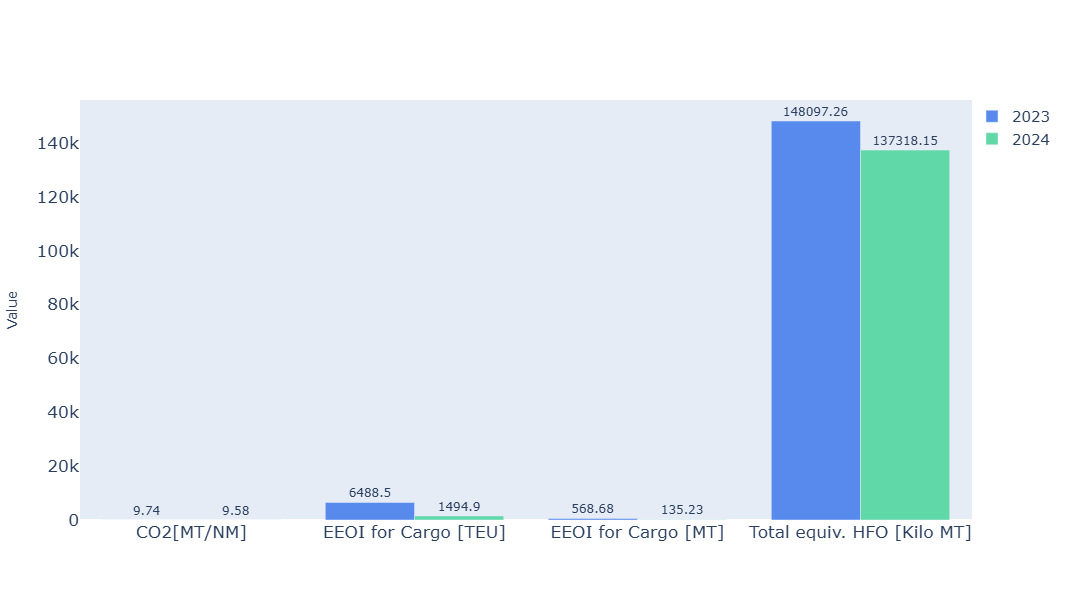

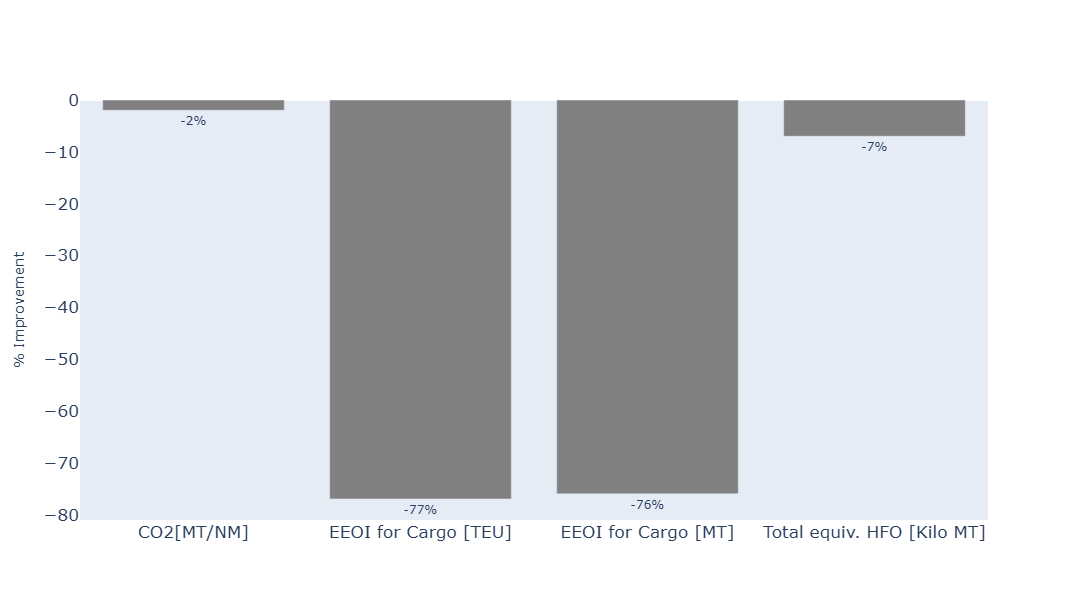

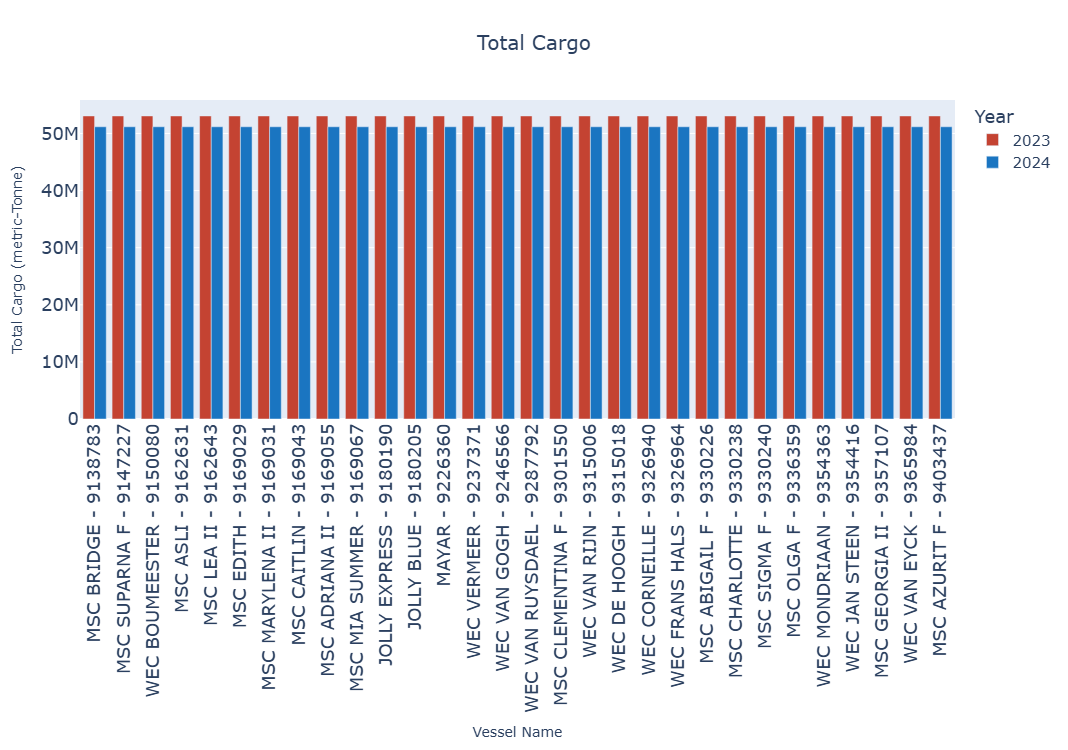

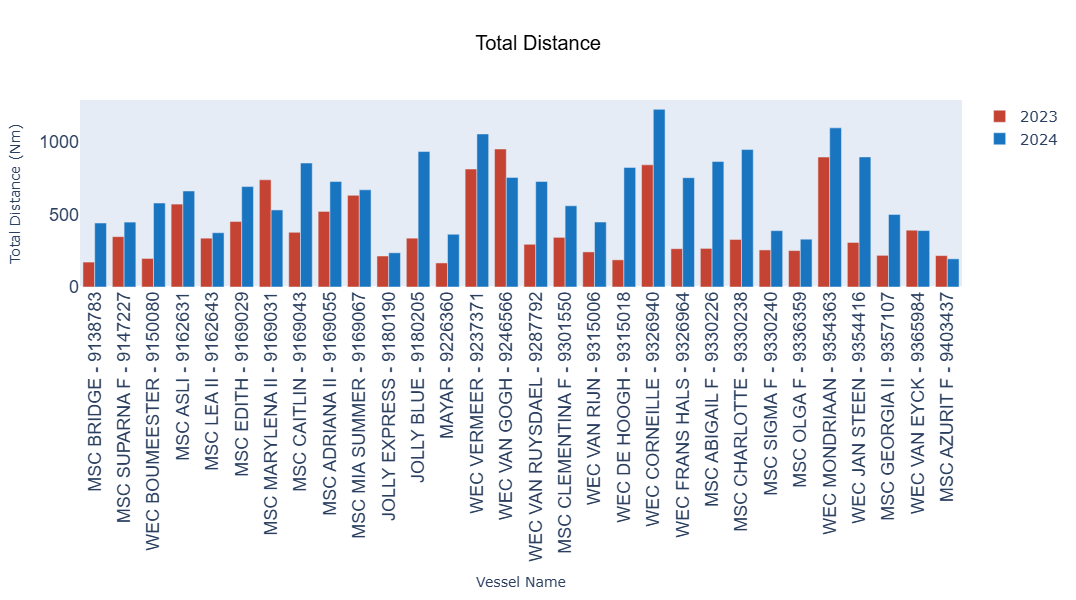

In [133]:
Table1 = pd.DataFrame.from_dict(s['data']['table1']['table1']).fillna(0)
Table1['improvement'] = Table1['improvement'].astype(float).astype(int)
Table1_str = Table1[['index', 'year1', 'year2', 'improvement']].astype(str)
Table1_str['improvement'] = Table1_str['improvement'] + ' %'

Table_1_head_Year = [['Year', first_Period, second_Period, '% Improvement']] if all((first_Period, second_Period)) else [['Year', str(first_Period_year), str(second_Period_year), '% Improvement']]
Table_1_Year = Table_1_head_Year + Table1_str.values.tolist()

# 2nd Table
Table_2 = Table1.set_index(['index'])
Table_2 = Table_2.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]].reset_index()

Table_2 = Table_2.rename({'improvement': 'Improvement (%)', 'year1': first_Period, 'year2': second_Period, 'index': 'Year'}, axis=1) if all((first_Period, second_Period)) else Table_2.rename({'improvement': 'Improvement (%)', 'year1': str(first_Period_year), 'year2': str(second_Period_year), 'index': 'Year'}, axis=1)

Table_2_new = Table_2.T.reset_index().T.set_index(0).T
Table_2_str = Table_2_new.astype(str)


FirstPeriodData = pd.DataFrame.from_dict(s['data']['FirstPeriodData'])
FirstPeriodData_1 = FirstPeriodData[['Vessel Name', 'Cargo Total (MT)', 'Cargo Total (TEU)', 'Distance (NM)','Number of Voyages','Total CO2 (MT)',
                                'Equivalent HFO (MT)','EEOI (gm/MT-NM)', 'EEOI (gm/TEU-NM)','Fuel per Miles(Kg/NM)','Distance per Voyage (NM)',
                                'Fuel Consumption per Voyage (MT)']].round(2)
# FirstPeriodData_1['eeoi_mt'] = FirstPeriodData_1['eeoi_mt'].astype('float32')
# FirstPeriodData_1['eeoi_teu'] = FirstPeriodData_1['eeoi_teu'].astype('float32')
FirstPeriodData_str = FirstPeriodData_1.astype(str)
SecondPeriodData = pd.DataFrame.from_dict(s['data']['SecondPeriodData'])
SecondPeriodData['Vessel Name'].nunique()
SecondPeriodData_1 = SecondPeriodData[['Vessel Name', 'Cargo Total (MT)', 'Cargo Total (TEU)', 'Distance (NM)','Number of Voyages','Total CO2 (MT)',
                                'Equivalent HFO (MT)','EEOI (gm/MT-NM)', 'EEOI (gm/TEU-NM)','Fuel per Miles(Kg/NM)','Distance per Voyage (NM)',
                                'Fuel Consumption per Voyage (MT)']].round(2)
SecondPeriodData_str = SecondPeriodData_1.astype(str)


vsl_name = pd.DataFrame.from_dict(s['vessel_data'])
col_vsl = dict(zip(vsl_name['imo'], vsl_name['name']))
#s = s['data']

Year1_Graph = pd.DataFrame.from_dict(s['data']['year1']['finaldata']).round(2)
Year2_Graph = pd.DataFrame.from_dict(s['data']['year2']['finaldata']).round(2)
EEOI_Analysis = Table1.set_index(['index'])
EEOI_Analysis = EEOI_Analysis.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]]
EEOI_Analysis = EEOI_Analysis[['year1', 'year2']]

EEOI_Analysis_new = EEOI_Analysis.rename({"year1": first_Period, 'year2': second_Period}, axis=1) if all((first_Period, second_Period)) else EEOI_Analysis.rename({"year1": str(first_Period_year), 'year2': str(second_Period_year)}, axis=1)

# EEOI_Analysis_Graph = EEOI_Analysis_new.plot.bar(rot=0, color={first_Period: "#588aee", second_Period: "#61d8a8"}, width=0.8, figsize=(10, 6))

EEOI_Analysis = Table1.set_index(['index'])
EEOI_Analysis = EEOI_Analysis.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]]
EEOI_Analysis = EEOI_Analysis[['year1', 'year2']]

EEOI_Analysis_1 = EEOI_Analysis_new.columns[0]
EEOI_Analysis_2 = EEOI_Analysis_new.columns[1]

# Create a bar chart for each trace with values above the bars
trace1 = go.Bar(
    x=EEOI_Analysis.index,
    y=EEOI_Analysis['year1'],
    text=EEOI_Analysis['year1'].round(2),  # Adjust rounding as needed
    textposition='outside',  # Display text labels outside the bars
    name=EEOI_Analysis_1,
    marker=dict(color="#588aee")
)

trace2 = go.Bar(
    x=EEOI_Analysis.index,
    y=EEOI_Analysis['year2'],
    text=EEOI_Analysis['year2'].round(2),
    textposition='outside',
    name=EEOI_Analysis_2,  # Use the dynamically generated legend label
    marker=dict(color="#61d8a8")
)

layout = go.Layout(
    xaxis=dict(
        title=' ',
        tickfont=dict(size=17),
        showgrid=False  # Correct syntax for showgrid
    ),
    yaxis=dict(
        title='Value',
        tickfont=dict(size=17),
        showgrid=False  # Correct syntax for showgrid
    ),
    showlegend=True,
    legend=dict(
        x=1,  # Adjust the x position of the legend
        y=1,  # Adjust the y position of the legend
        font=dict(size=15),  # Adjust the font size of the legend
        bgcolor='rgba(0, 0, 0, 0)'  # Make the legend background transparent
    ),
    width=1050,
    height=600
)

fig = go.Figure(data=[trace1, trace2], layout=layout)
fig.show()
plot_div = pyo.plot(fig, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})

Improvement_Percent = Table1.set_index(['index'])
Improvement_Percent = Improvement_Percent.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]]
Improvement_Percent = Improvement_Percent[['improvement']].reset_index()
Improvement_Percent = Improvement_Percent.set_index(['index'])

fig1 = go.Figure()

fig1.add_trace(go.Bar(
    x=Improvement_Percent.index,
    y=Improvement_Percent['improvement'],
    text=Improvement_Percent['improvement'].astype('str') + '%',
    textposition='outside',  # Display text outside the bar
    marker=dict(color='#808080')  
))

layout = go.Layout(
    xaxis=dict(
        title='',
        tickfont=dict(size=17),
        showgrid=False  # Correct syntax for showgrid
    ),
    yaxis=dict(
        title='% Improvement',
        tickfont=dict(size=17),
        showgrid=False  # Correct syntax for showgrid
    ),
    showlegend=False,
    width=1000,
    height=600
)
# Format y-axis tick labels as percentages
layout['yaxis']['tickformat'] = '.3f%'

fig1.update_layout(layout)

fig1.show()

plot_div2 = pyo.plot(fig1, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})

Energy_Efficiency = Year1_Graph[['imo', 'eeoi_mt']].rename(columns={'eeoi_mt': str(first_Period_year)})
Energy_Efficiency[str(second_Period or second_Period_year)] = Energy_Efficiency['imo'].map(
    Year2_Graph.set_index('imo')['eeoi_mt']
)
Energy_Efficiency['Vessel Name'] = Energy_Efficiency['imo'].map(col_vsl)

# Melt the data for easy plotting
melted_data = pd.melt(
    Energy_Efficiency, 
    id_vars=['Vessel Name'], 
    value_vars=[str(first_Period_year), str(second_Period or second_Period_year)],
    var_name='Year', 
    value_name='Energy_Efficiency'
)

# Create the bar plot
fig3 = px.bar(
    melted_data,
    x='Vessel Name',
    y='Energy_Efficiency',
    color='Year',
    color_discrete_sequence=['#c44332', '#1a75c1'],
    title='Energy Efficiency'
)

# Customize the layout
layout = go.Layout(
    title=dict(text='Energy Efficiency', font=dict(size=20), x=0.5),
    xaxis=dict(title='Vessel Name', tickfont=dict(size=18)),
    yaxis=dict(title='Energy Efficiency (g/Ton-Nm)', tickfont=dict(size=18)),
    legend=dict(font=dict(size=15), bgcolor='rgba(0, 0, 0, 0)'),
    barmode='group',
    width=1050,
    height=750
)

# Apply layout to the figure
fig3.update_layout(layout)

# Display the figure
#fig3.show()    
plot_div5 = pyo.plot(fig3, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})

Total_Cargo = Year1_Graph[['imo', 'cargomt']].rename(columns={'cargomt': str(first_Period_year)})

# Adding data from the second period (if available)
Total_Cargo[str(second_Period or second_Period_year)] = Total_Cargo['imo'].map(
    Year2_Graph.set_index('imo')['cargomt']
)

# Mapping the vessel name based on IMO
Total_Cargo['Vessel Name'] = Total_Cargo['imo'].map(col_vsl)

# Melting the data for easy plotting
melted_data_cargo = pd.melt(
    Total_Cargo, 
    id_vars=['Vessel Name'], 
    value_vars=[str(first_Period_year), str(second_Period or second_Period_year)],
    var_name='Year',  # Using 'Year' as the column name
    value_name='Total_Cargo'
)

# Create the bar plot with melted data
fig_cargo = px.bar(
    melted_data_cargo,
    x='Vessel Name',
    y='Total_Cargo',
    color='Year',  # Using 'Year' as the color column
    color_discrete_sequence=['#c44332', '#1a75c1'],
    title='Total Cargo'
)

# Customize the layout
layout_cargo = go.Layout(
    title=dict(text='Total Cargo', font=dict(size=20), x=0.5),
    xaxis=dict(title='Vessel Name', tickfont=dict(size=18), tickangle=-90),
    yaxis=dict(title='Total Cargo (metric-Tonne)', tickfont=dict(size=18)),
    legend=dict(font=dict(size=15), bgcolor='rgba(0, 0, 0, 0)'),
    barmode='group',
    width=1050,
    height=750
)

# Apply layout to the figure
fig_cargo.update_layout(layout_cargo)

# Display the figure
fig_cargo.show()



# Total Distance
Total_Distance = Year1_Graph[['imo', 'average_distance']].rename(columns={'average_distance': str(first_Period_year)})

# Adding second period data if available
if second_Period:
    Total_Distance[str(second_Period)] = Total_Distance['imo'].map(
        Year2_Graph.set_index('imo')['average_distance']
    )
else:
    Total_Distance[str(second_Period_year)] = Total_Distance['imo'].map(
        Year2_Graph.set_index('imo')['average_distance']
    )

# Mapping Vessel Names based on IMO numbers
Total_Distance['Vessel Name'] = Total_Distance['imo'].map(col_vsl)

# Renaming the period column to the first period year
if first_Period != 'null':
    Total_Distance = Total_Distance.rename({str('average_distance'): first_Period}, axis=1)
else:
    Total_Distance = Total_Distance.rename({str('average_distance'): str(first_Period_year)}, axis=1)

# Melting the data for easy plotting
melted_data_distance = pd.melt(
    Total_Distance,
    id_vars=['Vessel Name'],
    value_vars=[str(first_Period), str(second_Period or second_Period_year)],
    var_name='Year',  # This will label the period/year column as 'Year'
    value_name='Total_Distance'
)

# Create the bar plot using Plotly Express
fig_distance = px.bar(
    melted_data_distance,
    x='Vessel Name',
    y='Total_Distance',
    color='Year',  # Color bars based on the 'Year' column
    color_discrete_sequence=['#c44332', '#1a75c1'],
    title='Total Distance'
)

# Customize the layout for the graph
layout_total_distance = go.Layout(
    title=dict(
        text='Total Distance', 
        font=dict(size=20, family='Roboto, sans-serif', color='black'),
        x=0.5  # Center the title horizontally
    ),
    xaxis=dict(
        title='Vessel Name',
        tickfont=dict(size=18, family='Roboto, sans-serif'),
        showgrid=False,
        tickangle=-90# Hides the gridlines for the x-axis
    ),
    yaxis=dict(
        title='Total Distance (Nm)',
        tickfont=dict(size=18, family='Roboto, sans-serif'),
        showgrid=False  # Hides the gridlines for the y-axis
    ),
    legend=dict(
        title='',  # Remove legend title
        font=dict(size=15),  # Adjust the font size of the legend
        bgcolor='rgba(0, 0, 0, 0)'  # Make the legend background transparent
    ),
    barmode='group',  # Group bars for each vessel
    width=1000,
    height=600
)

# Apply layout to the figure
fig_distance.update_layout(layout_total_distance)

# Display the plot
fig_distance.show()

# Save or display the figure
plot_div9 = pyo.plot(Total_Distance_Graph, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})


Table_3_head_Year=[['Vessel Name','Cargomt','Cargoteu','Distance','EEOI_Voy_no','Totalco2_mt','Totalco2_kgnm',
                                                'EEOI_mt', 'EEOI_teu','Fuelkg_nm','Average Distance','Average Fuelcons']]

Table_3_Year1 =Table_3_head_Year+ FirstPeriodData_str.values.tolist()

Table_4_head_Year=[['Vessel Name','Cargomt','Cargoteu','Distance','EEOI_Voy_no','Totalco2_mt','Totalco2_kgnm',
                                    'EEOI_mt', 'EEOI_teu','Fuelkg_nm','Average Distance','Average Fuelcons']]


Table_4_Year2 =Table_4_head_Year+ SecondPeriodData_str.values.tolist()


In [35]:
# Replace 'energy_efficiency_column' and 'total_cargo_column' with actual column names
Energy_Efficiency = df['energy_efficiency_column']  # Ensure this column exists
Total_Cargo = df['total_cargo_column']  # Ensure this column exists

# Debug print to verify data
print("Energy Efficiency data:", Energy_Efficiency.head())
print("Total Cargo data:", Total_Cargo.head())


NameError: name 'df' is not defined

In [ ]:

html_table = "<table border='1'>\n"
# Create table header
html_table += "<tr>"
for col in Table_1_Year[0]:
    html_table += f"<th>{col}</th>"
html_table += "</tr>\n"

# Iterate over rows
for row in Table_1_Year[1:]:
    html_table += "<tr>"
    for value in row:
        html_table += f"<td>{value}</td>"
    html_table += "</tr>\n"

html_table += "</table>"

html_table2 = "<table border='1'>\n"
# Create table header
html_table2 += "<tr>"
for col in Table_2_new.columns:
    html_table2 += f"<th>{col}</th>"
html_table2 += "</tr>\n"

# Iterate over rows
for index, row in Table_2_new.iterrows():
    html_table2 += "<tr>"
    for value in row:
        html_table2 += f"<td>{value}</td>"
    html_table2 += "</tr>\n"

html_table2 += "</table>"

html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title> YEAR 2023-2024 EEOI ANALYSIS </title>
    <style>
        body {{
            text-align: center;
            font-family: 'Roboto', sans-serif;
            color: #333;
            background-color: #fff;
        }}
        h1 {{
            color: #193185;
            font-size: 36px;
            margin-bottom: 20px;
        }}
        h2{{
            color: #193185;
            font-size: 30px; 

        }}
        img {{
            width: 100px;
            float: right;
        }}
        .info {{
            text-align: left;
            margin-left: 20px;
            display: flex;
            font-size: 16px;
            font-weight: bold;
        }}

        .second-info{{ margin-left: 100px;}}
        table {{
            margin: 20px auto;
                width: 65%;
                border-collapse: collapse;
                border: solid;

        }}

            table, tr, td {{height: 30px;
                border: 1px solid;
            }}
        .plot_div{{
                    width: 100%;
                    display: flex;
                    justify-content: center;
        }}

        hr {{
            border-width: 3px;
            border-color: #33;
            margin-top: 20px;
            border-style: solid; /* Add border style */
        }}


        th {{
    background: blue;
    color: white;
    height: 41px;
}}
    </style>
</head>
<body>
    <br>
    <br>
    {image_tag}
    
    <br>
    <br>
    <br>
    <h1>YEAR 2023-2024 EEOI ANALYSIS </h1>  
    <hr>
    <br>
    <div class="info">
        <div class='first-info'>
        <p>Fleet:{fleet}</p>
        {
            "<p>First Period: "+ first_Period + "</p><p> Second Period: " + second_Period + "</p>" if first_Period and second_Period != 'null' else
            "<p>First Period: " + first_period_min + " to " + first_period_max  + "</p>"
            "<p>Second Period: " + second_period_min + " to " + second_period_max + "</p>"}        
        </div>
    </div>
    <hr>
    <br>
    {html_table}
    <br>
    <h2>YEARLY EEOI ANALYSIS</h2>
    <!-- Add the centered and bigger table -->
    <br>
    {html_table2}
    <br>
    <br>
    <br>
    <h2>EEOI ANALYSIS</h2>
    <div class="plot_div">
        {plot_div}
    </div>
    <br>
    <br>
    <h2>YEARLY % IMPROVEMENT- EEOI ANALYSIS</h2>
    <div class="plot_div">
        {plot_div2}
    </div>
    <br>
    <br>
    <h2>ENERGY EFFICENCY (GM/TONNE-MILE)</h2>
    <div class="plot_div">
        {plot_div5}
    </div>
    <br>
    <br>
    <h2>TOTAL CARGO</h2>
    <div class="plot_div">
        {plot_div7}
    </div>

    <h2>TOTAL DISATNCE</h2>
    <div class="plot_div">
        {plot_div9}
    </div>
    <br>
</body>
</html>
"""
print("fleeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeet")
print("fleeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeet",report_type)